In [13]:
import numpy as np
from pathlib import Path

DATA_PATH = Path().resolve().parent.parent / "data" 
DATASET = "mnist" 

In [14]:
train_np = np.load(DATA_PATH / DATASET / "train.npz")
print(train_np)
images = train_np["img"]
labels = train_np["label"]
images = images.squeeze(-1)


NpzFile '/home/sebastian/dev/mine/liquid/data/mnist/train.npz' with keys: img, label


In [15]:
images_flatten = images.reshape([images.shape[0], images.shape[1] * images.shape[1]])
images_flatten.shape

(60000, 784)

In [16]:
#Run training of a ensemble
import sys 
import jax
import jax.numpy as jnp
sys.path.insert(0, '/home/sebastian/dev/mine/liquid/liquid_jax')
from learner_mnist_le import LeMnistLearner, LeMlp, DeModelMlp
from liquid_solver import LEsolver, LEInfo
from structs import TrainParams
from mnist import Mnist
from pathlib import Path
from run_ablation_experiment import train, plot_losses, loss_fn, train_batch
from datetime import datetime


100%|██████████| 20/20 [00:20<00:00,  1.01s/it]


['validation_loss', 'validation_ce_loss', 'validation_load_distribution_loss', 'validation_specialization_losss', 'loss', 'ce_loss', 'load_distribution_loss', 'specialization_losss']
saving to/home/sebastian/dev/mine/liquid/liquid_jax/notebooks/experiments/ablation/20260312_173231


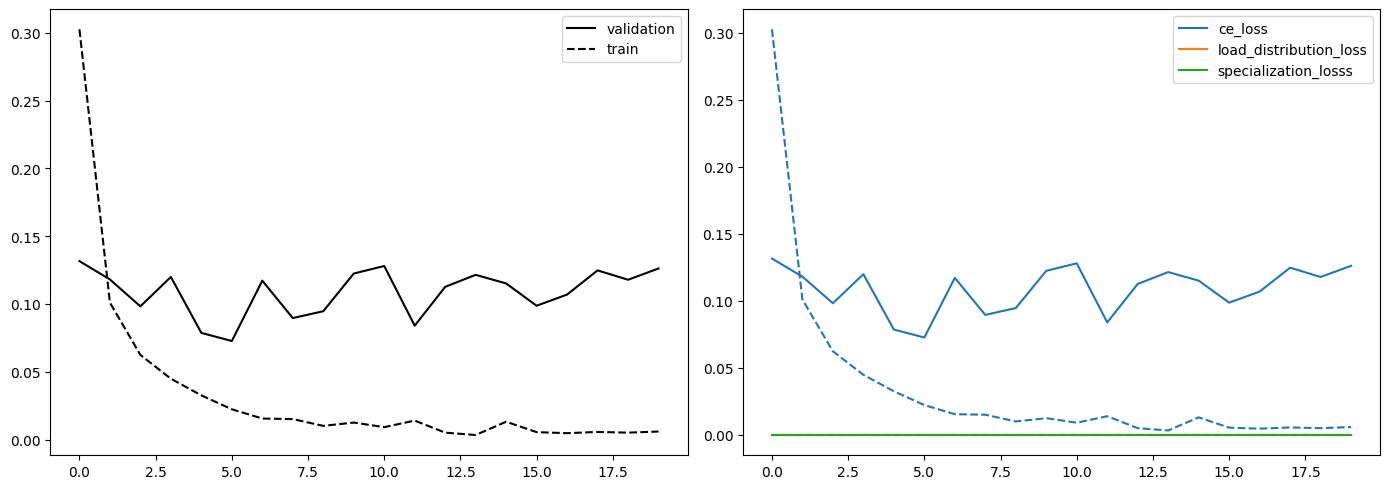

In [ ]:
key = jax.random.key(42)

Mnist.folder = folder = Path().resolve().parent.parent / "data" / "mnist"
params = TrainParams(
    batch_size=512,
    preload_batches_to_gpu=5,
    valid_batches=2,
    epochs=20,
    lr=1e-3,
    optimizer="adam",
    performance_loss="ce",
    task=Mnist,
    learner=LeMnistLearner
)

metrics = train(key, params)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")      
output_path = Path().resolve() / "experiments" / "ablation" / timestamp                                                                                                              
plot_losses(output_path, metrics, save=False)

In [ ]:
boddy_hidd_dim = 128

model = LeMnistLearner.get_model()
model

LeMlp(
    # attributes
    n_models = 10
    out = (32, 10)
    delegation = (32, 10)
    body = (128, 64)
)

In [19]:
print(images_flatten.shape)
print(labels.shape)

(60000, 784)
(60000,)


In [20]:
def count_params(input_dim, body, out, delegation):                                                                                                                                                                                                      
      """Count parameters per component for a single expert."""                                                                                                                                                                                            
      def _layers(in_dim, neurons):                                                                                                                                                                                                                        
          total, prev = 0, in_dim                                                                                                                                                                                                                        
          for n in neurons:
              total += prev * n + n  # weights + bias
              prev = n
          return total

      body_out = body[-1] if body else input_dim
      bp = _layers(input_dim, body) if body else 0
      op = _layers(body_out, out)
      dp = _layers(body_out, delegation)
      return {"body": bp, "out": op, "del": dp, "total": bp + op + dp}

In [21]:
count_params(784, body=(128, 64), out=(32, 10), delegation=(32, 10))

{'body': 108736, 'out': 2410, 'del': 2410, 'total': 113556}

In [22]:
def solve_hidden_dims(total_budget, body_pct, out_pct, del_pct,
                        input_dim=784, body_out=64, n_classes=10, n_models=10):
      """Solve for hidden widths given a param budget and percentages."""
      # params = h * (in + 1 + out) + out  →  h = (budget - out) / (in + 1 + out)
      h_body = int((total_budget * body_pct - body_out) / (input_dim + 1 + body_out))
      h_out  = int((total_budget * out_pct - n_classes) / (body_out + 1 + n_classes))
      h_del  = int((total_budget * del_pct - n_models) / (body_out + 1 + n_models))

      print(f"h_body={h_body}, h_out={h_out}, h_del={h_del}")

      body = (h_body, body_out)
      out = (h_out, n_classes)
      delegation = (h_del, n_models)
      return body, out, delegation

In [23]:
body, out, deleg = solve_hidden_dims(5000, body_pct=0.10, out_pct=0.40, del_pct=0.50)

h_body=0, h_out=26, h_del=33


In [2]:
import pandas as pd

df = pd.read_parquet("/home/s6019595/liquid/experiments/ablation/20260313_122246/results.parquet")

In [7]:
df.head(10)

,h_body,h_out,h_del,body,out,delegation,skip,actual_params,body_params,head_in,final_val_loss,final_train_loss,best_val_loss,best_val_ce_loss,final_val_ce_loss
0,0,31,31,None,"[31, 10]","[31, 10]",False,49310,0,784,0.121927,0.005972,0.084279,0.084279,0.121927
1,1,327,327,"[1, 64]","[327, 10]","[327, 10]",False,49983,913,64,0.182051,0.161612,0.169660,0.169660,0.182051
2,6,299,299,"[6, 64]","[299, 10]","[299, 10]",False,50028,5158,64,0.136119,0.014316,0.085695,0.085695,0.136119
3,11,271,271,"[11, 64]","[271, 10]","[271, 10]",False,50073,9403,64,0.120828,0.007793,0.067708,0.067708,0.120828
4,16,242,242,"[16, 64]","[242, 10]","[242, 10]",False,49968,13648,64,0.140987,0.009862,0.072545,0.072545,0.140987
5,21,214,214,"[21, 64]","[214, 10]","[214, 10]",False,50013,17893,64,0.109594,0.002667,0.075784,0.075784,0.109594
6,26,186,186,"[26, 64]","[186, 10]","[186, 10]",False,50058,22138,64,0.108159,0.005360,0.086864,0.086864,0.108159
7,31,157,157,"[31, 64]","[157, 10]","[157, 10]",False,49953,26383,64,0.145752,0.008910,0.083249,0.083249,0.145752
8,36,129,129,"[36, 64]","[129, 10]","[129, 10]",False,49998,30628,64,0.080815,0.010682,0.074239,0.074239,0.080815
9,41,101,101,"[41, 64]","[101, 10]","[101, 10]",False,50043,34873,64,0.073138,0.000118,0.068163,0.068163,0.073138


## Diagnosing CE-Only Training Instability

Training the Liquid Ensemble with **only CE loss** (no load balancing, no specialization).  
Collecting per-expert diagnostics each epoch to understand:
- **Power concentration**: Do some experts dominate?
- **Per-expert quality**: Are starved experts actually worse, or just ignored?
- **Delegation patterns**: What is the delegation head learning?
- **Gradient starvation**: How does power weighting affect effective gradient signal?

In [ ]:
# ── Setup: CE-only Training with Per-Expert Diagnostics ───────────
from functools import partial
from collections import defaultdict
import math

import jax
import jax.numpy as jnp
import numpy as np
import optax
import tqdm
from pathlib import Path

import sys
sys.path.insert(0, '/home/sebastian/dev/mine/liquid/liquid_jax')

from train import train_loader, InOutData, train_batch, loss_fn
from liquid_solver import LEsolver, LEInfo
from learner_mnist_le import LeMlp
from learner_base import Learner
from structs import TrainParams
from mnist import Mnist

Mnist.folder = Path().resolve().parent.parent / "data" / "mnist"

ce_solver = LEsolver(
    solver="sink_many",
    load_distribution_lambda=0.0,
    specialization_lambda=0.0,
)

def make_ce_learner(n_models=10, body=(128, 64), out_head=(32, 10)):
    """Factory for a Learner that uses CE loss only (no aux losses)."""
    deleg_head = (32, n_models)

    class _L(Learner[LEInfo]):
        @staticmethod
        def get_model():
            return LeMlp(n_models=n_models, body=body, out=out_head, delegation=deleg_head)

        @staticmethod
        def forward(key, x, model, params):
            ys, d = model.apply({"params": params}, x)
            info = ce_solver.solve_power(d)
            return ce_solver.mix_power_logits(ys, info.power), info

        @staticmethod
        def auxillary_losses(key, train_return):
            return {
                "load_distribution_loss": jnp.float32(0.0),
                "specialization_losss": jnp.float32(0.0),
            }

    return _L


@partial(jax.jit, static_argnames=("model",))
def _fwd(params, model, x):
    ys, d = model.apply({"params": params}, x)
    power = ce_solver.solve_power(d).power
    return ys, d, power


def collect_diag(model_params, model, ex, ey):
    """Collect per-expert diagnostics on eval data."""
    ys, D_mat, power = _fwd(model_params, model, ex)
    n_m = ys.shape[1]
    n_c = ys.shape[2]

    # Per-expert CE loss (each expert evaluated independently)
    lp = jax.nn.log_softmax(ys, axis=-1)
    oh = jax.nn.one_hot(ey, n_c)
    expert_ce = -jnp.sum(lp * oh[:, None, :], axis=-1)  # (batch, n_models)

    # Per-expert accuracy
    preds = jnp.argmax(ys, axis=-1)
    expert_acc = (preds == ey[:, None]).astype(jnp.float32)

    # Power entropy (normalized: 1=uniform, 0=concentrated)
    pd = power / power.sum(axis=-1, keepdims=True)
    ent = -jnp.sum(pd * jnp.log(pd + 1e-10), axis=-1) / jnp.log(n_m)

    # Winner counts (which expert has highest power per sample)
    winners = jnp.argmax(power, axis=1)
    w_oh = jax.nn.one_hot(winners, n_m)

    return {
        'expert_ce': np.array(jnp.mean(expert_ce, axis=0)),         # (n_models,)
        'expert_acc': np.array(jnp.mean(expert_acc, axis=0)),       # (n_models,)
        'mean_power': np.array(jnp.mean(power, axis=0)),            # (n_models,)
        'power_std': np.array(jnp.std(power, axis=0)),              # (n_models,)
        'mean_D': np.array(jnp.mean(D_mat, axis=0)),                # (n_models, n_models)
        'power_entropy': float(jnp.mean(ent)),                      # scalar
        'winner_counts': np.array(w_oh.sum(axis=0)),                 # (n_models,)
        'pw_ce': np.array(jnp.mean(expert_ce * (power / n_m), axis=0)),  # power-weighted CE
    }


def train_diag(key, train_params, n_eval=6000):
    """Train with CE only, collecting per-expert diagnostics each epoch."""
    gpu = jax.devices("gpu")[0]
    key, k_init, k_loop, k_loader = jax.random.split(key, 4)

    # Data
    data = train_params.task.load_cpu(split="train")
    x, y = train_params.task.get_xy(data)
    inout = InOutData(x=x, y=y)
    gpu_batch = train_params.batch_size * train_params.preload_batches_to_gpu
    n_batches = math.ceil(x.shape[0] / gpu_batch)

    n_valid = train_params.batch_size * train_params.valid_batches
    inout_valid = jax.tree.map(lambda a: jax.device_put(a[:n_valid], device=gpu), inout)
    inout_train = jax.tree.map(lambda a: a[n_valid:], inout)

    ex = jax.device_put(x[:n_eval], device=gpu)
    ey = jax.device_put(y[:n_eval], device=gpu)

    # Model + optimizer
    model = train_params.learner.get_model()
    mp = model.init(k_init, x[[0]])["params"]
    opt = {"sgd": optax.sgd(learning_rate=train_params.lr),
           "adam": optax.adamw(learning_rate=train_params.lr)}[train_params.optimizer]
    opt_state = opt.init(mp)

    metrics = defaultdict(list)
    diags = []

    # Epoch 0 diagnostics (before any training)
    diags.append(collect_diag(mp, model, ex, ey))

    for ep in tqdm.tqdm(range(train_params.epochs)):
        ep_m = defaultdict(list)

        for batch, k_loader in train_loader(
            k_loader, inout_train, batch_size=gpu_batch, desired_batches=n_batches
        ):
            k_loop, k_use = jax.random.split(k_loop)
            batch = jax.tree.map(lambda a: jax.device_put(a, device=gpu), batch)
            (mp, opt_state), (loss, losses) = train_batch(
                key=k_use, inout_data=batch, model_params=mp,
                opt_state=opt_state, optimizer=opt, model=model,
                train_params=train_params,
            )
            ep_m["loss"].append(loss)
            for k, v in losses.items():
                ep_m[k].append(v.item())

        k_loop, k_use = jax.random.split(k_loop)
        vl, vls = loss_fn(mp, k_use, inout_valid, model, train_params)
        metrics["val_loss"].append(vl.item())
        for k, v in vls.items():
            metrics[f"val_{k}"].append(v.item())
        for k, v in ep_m.items():
            metrics[k].append(np.mean(v))

        diags.append(collect_diag(mp, model, ex, ey))

    # Stack diagnostics into arrays: D[key] has shape (n_epochs+1, ...)
    D = {k: np.array([d[k] for d in diags]) for k in diags[0]}
    return metrics, D

print("Setup complete.")

Setup complete.


In [ ]:
N_MODELS = 10
EPOCHS = 100

key = jax.random.key(42)

tp = TrainParams(
    batch_size=512,
    preload_batches_to_gpu=5,
    valid_batches=2,
    epochs=EPOCHS,
    lr=1e-3,
    optimizer="adam",
    performance_loss="ce",
    task=Mnist,
    learner=make_ce_learner(n_models=N_MODELS)
)

metrics, D = train_diag(key, tp, n_eval=60000)
print(f"Final val CE: {metrics['val_ce_loss'][-1]:.4f}")
print(f"Final power entropy: {D['power_entropy'][-1]:.4f}")

100%|██████████| 100/100 [00:45<00:00,  2.21it/s]

Final val CE: 0.1589
Final power entropy: 0.7734


In [ ]:
import matplotlib.pyplot as plt

n_models = D['expert_ce'].shape[1]
n_snap = D['mean_D'].shape[0]
colors = [plt.cm.tab10(i) for i in range(n_models)]
epochs_axis = np.arange(n_snap)  # includes epoch 0 (before training)

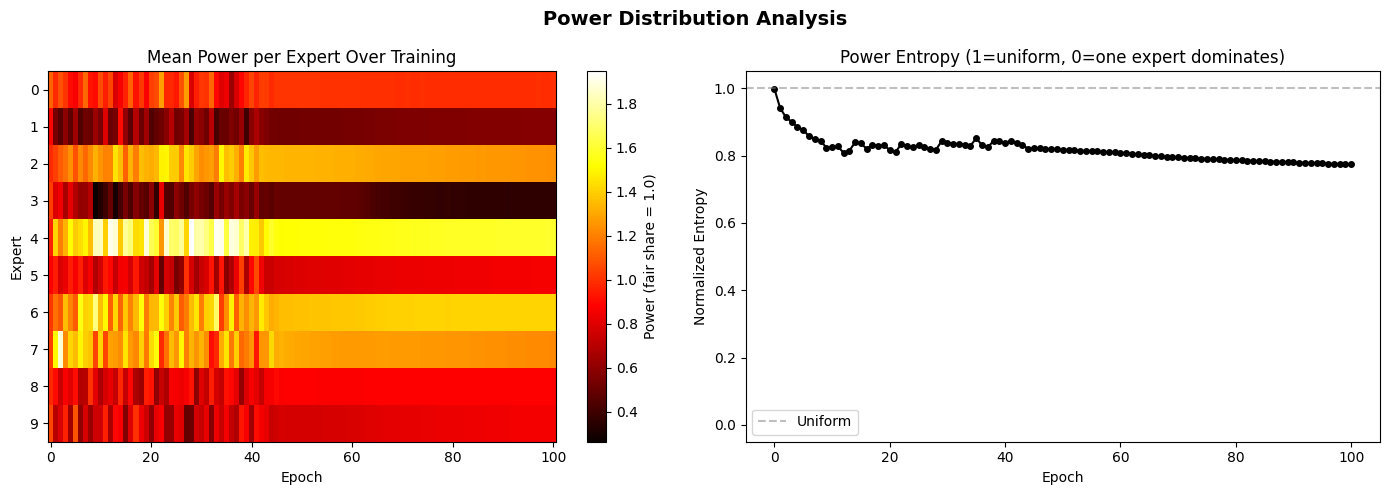

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

im = ax1.imshow(D['mean_power'].T, aspect='auto', cmap='hot', interpolation='nearest')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Expert')
ax1.set_title('Mean Power per Expert Over Training')
ax1.set_yticks(range(n_models))
plt.colorbar(im, ax=ax1, label='Power (fair share = 1.0)')

ax2.plot(epochs_axis, D['power_entropy'], 'k-o', markersize=4)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Normalized Entropy')
ax2.set_title('Power Entropy (1=uniform, 0=one expert dominates)')
ax2.set_ylim(-0.05, 1.05)
ax2.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Uniform')
ax2.legend()
fig.suptitle('Power Distribution Analysis', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

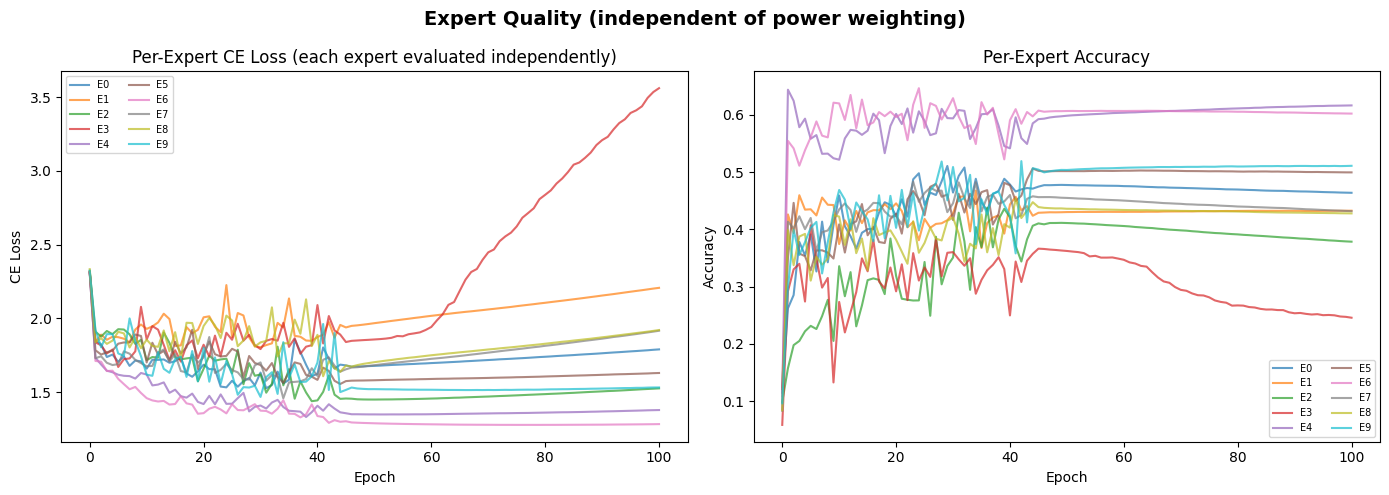

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for i in range(n_models):
    ax1.plot(epochs_axis, D['expert_ce'][:, i], color=colors[i], alpha=0.7, label=f'E{i}')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('CE Loss')
ax1.set_title('Per-Expert CE Loss (each expert evaluated independently)')
ax1.legend(fontsize=7, ncol=2)

for i in range(n_models):
    ax2.plot(epochs_axis, D['expert_acc'][:, i], color=colors[i], alpha=0.7, label=f'E{i}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Per-Expert Accuracy')
ax2.legend(fontsize=7, ncol=2)

fig.suptitle('Expert Quality (independent of power weighting)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

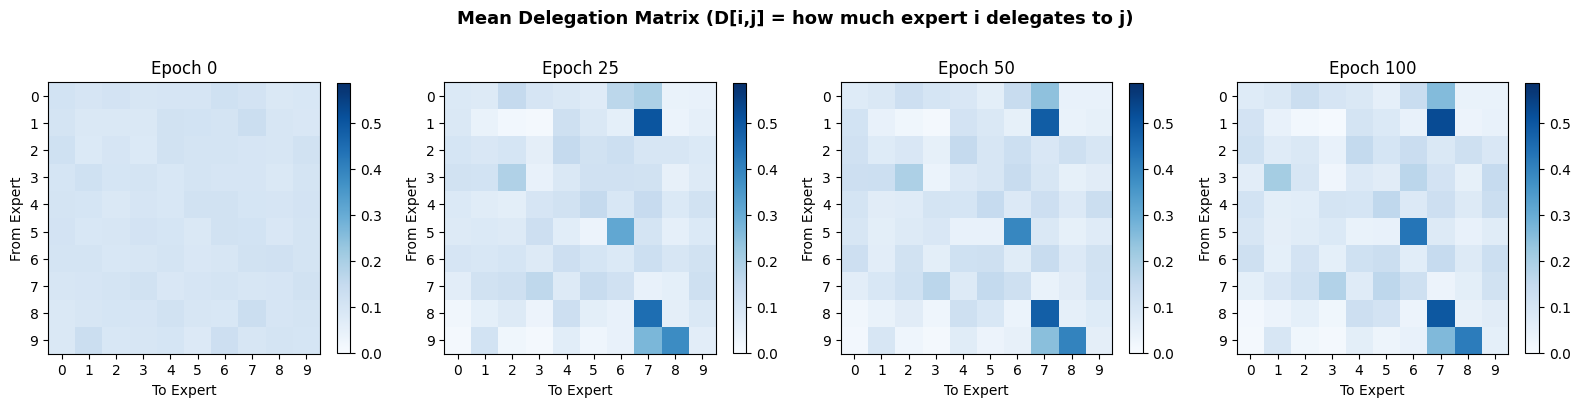

In [10]:
snap_idxs = [0, n_snap // 4, n_snap // 2, n_snap - 1]
fig, axes = plt.subplots(1, len(snap_idxs), figsize=(4 * len(snap_idxs), 4))

for ax, idx in zip(axes, snap_idxs):
    im = ax.imshow(D['mean_D'][idx], cmap='Blues', vmin=0, vmax=D['mean_D'].max())
    ax.set_title(f'Epoch {idx}')
    ax.set_xlabel('To Expert')
    ax.set_ylabel('From Expert')
    ax.set_xticks(range(n_models))
    ax.set_yticks(range(n_models))
    plt.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle('Mean Delegation Matrix (D[i,j] = how much expert i delegates to j)', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

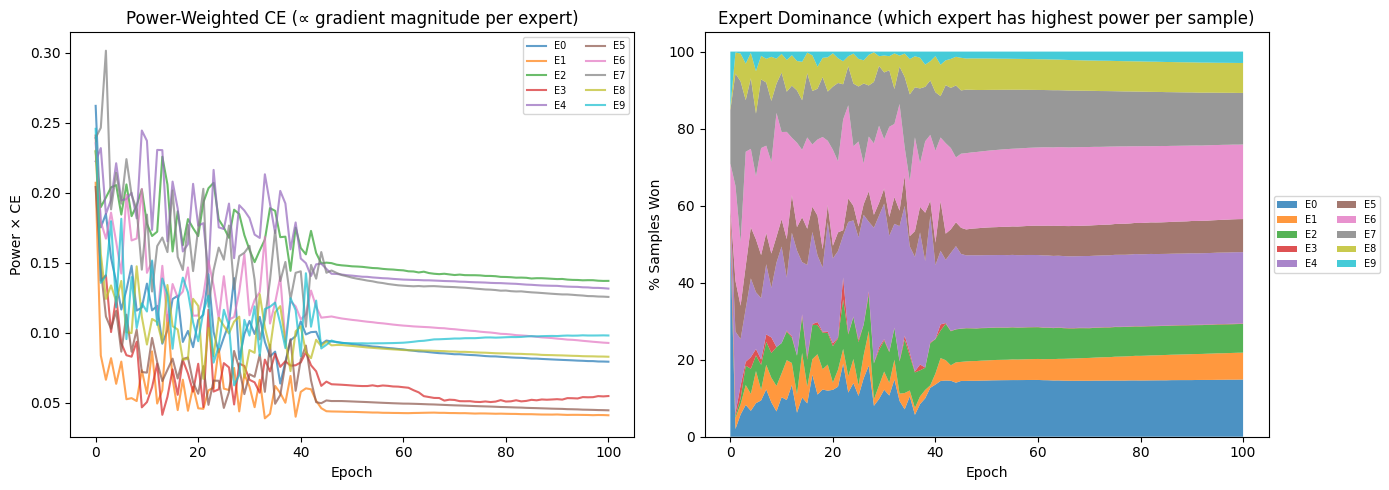

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for i in range(n_models):
    ax1.plot(epochs_axis, D['pw_ce'][:, i], color=colors[i], alpha=0.7, label=f'E{i}')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Power × CE')
ax1.set_title('Power-Weighted CE (∝ gradient magnitude per expert)')
ax1.legend(fontsize=7, ncol=2)

n_eval = D['winner_counts'][0].sum()
winner_pct = D['winner_counts'] / n_eval * 100
ax2.stackplot(epochs_axis, winner_pct.T, colors=colors, alpha=0.8,
              labels=[f'E{i}' for i in range(n_models)])
ax2.set_xlabel('Epoch')
ax2.set_ylabel('% Samples Won')
ax2.set_title('Expert Dominance (which expert has highest power per sample)')
ax2.legend(fontsize=7, ncol=2, loc='center left', bbox_to_anchor=(1, 0.5))

fig.tight_layout()
plt.show()

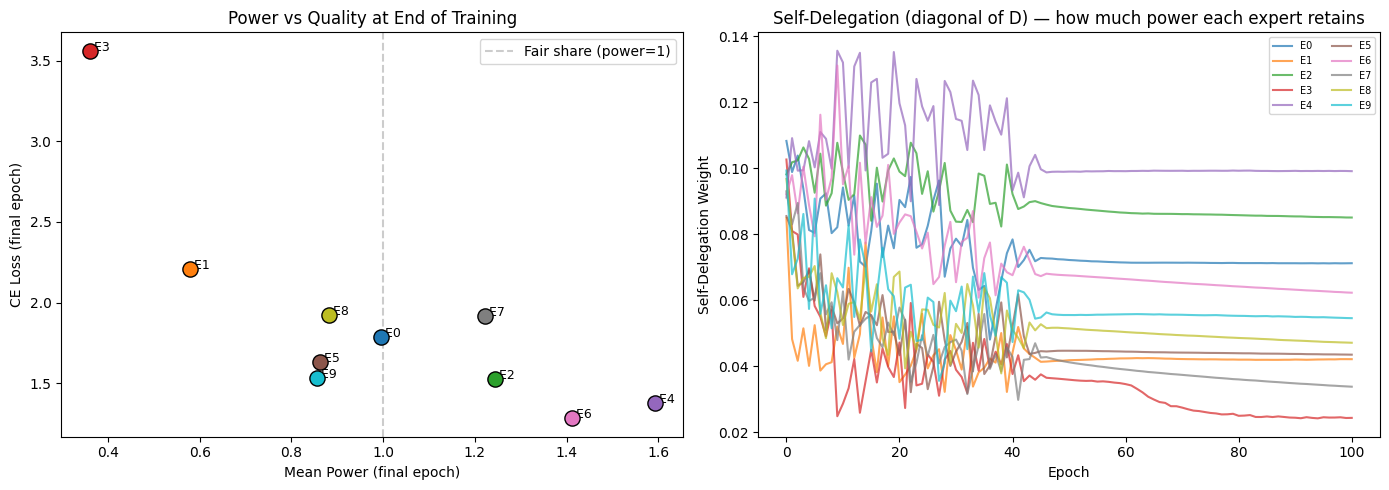

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: power vs CE at final epoch
final_p = D['mean_power'][-1]
final_ce = D['expert_ce'][-1]
for i in range(n_models):
    ax1.scatter(final_p[i], final_ce[i], color=colors[i], s=120, zorder=5, edgecolors='black')
    ax1.annotate(f' E{i}', (final_p[i], final_ce[i]), fontsize=9)
ax1.set_xlabel('Mean Power (final epoch)')
ax1.set_ylabel('CE Loss (final epoch)')
ax1.set_title('Power vs Quality at End of Training')
ax1.axvline(x=1.0, color='gray', linestyle='--', alpha=0.4, label='Fair share (power=1)')
ax1.legend()

# Self-delegation over time
self_deleg = np.array([D['mean_D'][t].diagonal() for t in range(n_snap)])
for i in range(n_models):
    ax2.plot(epochs_axis, self_deleg[:, i], color=colors[i], alpha=0.7, label=f'E{i}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Self-Delegation Weight')
ax2.set_title('Self-Delegation (diagonal of D) — how much power each expert retains')
ax2.legend(fontsize=7, ncol=2)

fig.tight_layout()
plt.show()

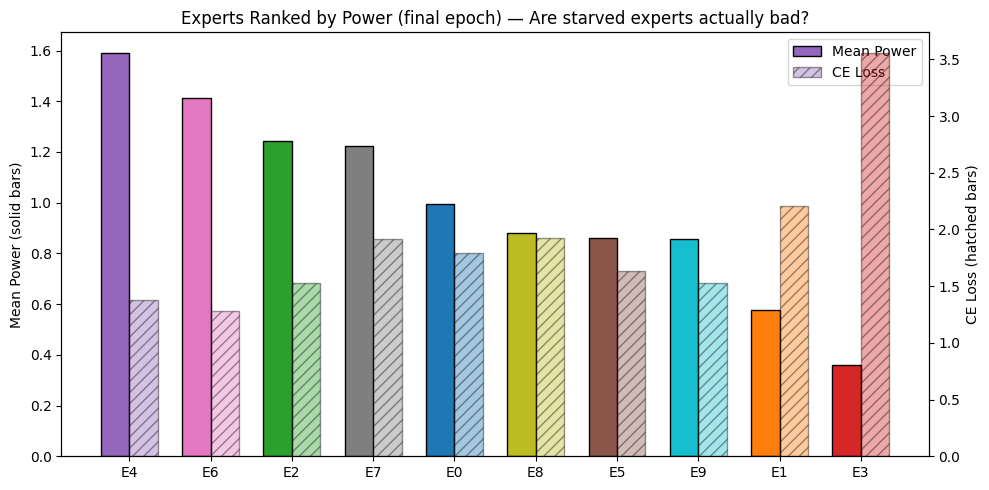

In [13]:
fig, ax1 = plt.subplots(1, 1, figsize=(10, 5))
ax2 = ax1.twinx()

order = np.argsort(final_p)[::-1]  # highest power first
x_pos = np.arange(n_models)
bar_width = 0.35

bars1 = ax1.bar(x_pos - bar_width/2, final_p[order], bar_width,
                color=[colors[i] for i in order], edgecolor='black', label='Mean Power')
bars2 = ax2.bar(x_pos + bar_width/2, final_ce[order], bar_width,
                color=[colors[i] for i in order], edgecolor='black', alpha=0.4, 
                hatch='///', label='CE Loss')

ax1.set_xticks(x_pos)
ax1.set_xticklabels([f'E{i}' for i in order])
ax1.set_ylabel('Mean Power (solid bars)')
ax2.set_ylabel('CE Loss (hatched bars)')
ax1.set_title('Experts Ranked by Power (final epoch) — Are starved experts actually bad?')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

fig.tight_layout()
plt.show()